# K-Means - H&M (simple)


Evaluación del número de clusters y ajuste final del modelo. Se comparan las métricas internas y se analizan los perfiles obtenidos para las configuraciones seleccionadas.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import kmeans_metrics, plot_clustering_metrics, analyze_clusters, fit_clustering_model, save_clustering_metrics
import pandas as pd
import time

## Carga y preparación de los datos


In [2]:
df_scaled = pd.read_csv("../../../scaled_data/hym_scaled.csv")

In [3]:
df_simple = pd.read_csv("../../../simple_datasets/hym_model_simple.csv")

In [4]:
df_scaled = df_scaled[df_scaled.columns.intersection(df_simple.columns)]

In [5]:
# Variables utilizadas para clustering
X = df_scaled.drop(columns=["customer_id"], errors="ignore")

## Evaluación del número de clusters


In [6]:
resultados_kmeans = kmeans_metrics(X)

In [7]:
tabla_metricas = save_clustering_metrics(
    resultados_kmeans,
    model_name="kmeans",
    dataset_name="hym",
    dataset_version="simple",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

Métricas consolidadas en ../../../results/clustering_metrics.csv


,model,dataset,dataset_version,k,silhouette,calinski_harabasz,davies_bouldin,inertia,tiempo_segundos,n_clusters_found,fpc,objective_function,iterations,bic,aic
0,birch,hym,extended,2,0.340654,930935.773165,1.105585,NaN,56.925452,2.0,NaN,NaN,NaN,NaN,NaN
1,birch,hym,extended,3,0.230760,688890.908136,1.436553,NaN,55.993544,3.0,NaN,NaN,NaN,NaN,NaN
2,birch,hym,extended,4,0.203823,524871.689920,1.792945,NaN,55.849959,4.0,NaN,NaN,NaN,NaN,NaN
3,birch,hym,extended,5,0.191449,438249.783633,1.834154,NaN,56.909790,5.0,NaN,NaN,NaN,NaN,NaN
4,birch,hym,extended,6,0.148712,376866.681427,2.094143,NaN,56.928501,6.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,minibatch,instacart,simple,6,0.287861,92542.785246,1.110500,191238.961903,0.476716,NaN,NaN,NaN,NaN,NaN,NaN
248,minibatch,instacart,simple,7,0.287363,88688.845444,1.083745,173472.413504,0.090507,NaN,NaN,NaN,NaN,NaN,NaN
249,minibatch,instacart,simple,8,0.284887,90539.561492,1.089686,152061.334109,0.358054,NaN,NaN,NaN,NaN,NaN,NaN
250,minibatch,instacart,simple,9,0.282639,87440.639855,1.070433,140993.880428,0.330287,NaN,NaN,NaN,NaN,NaN,NaN


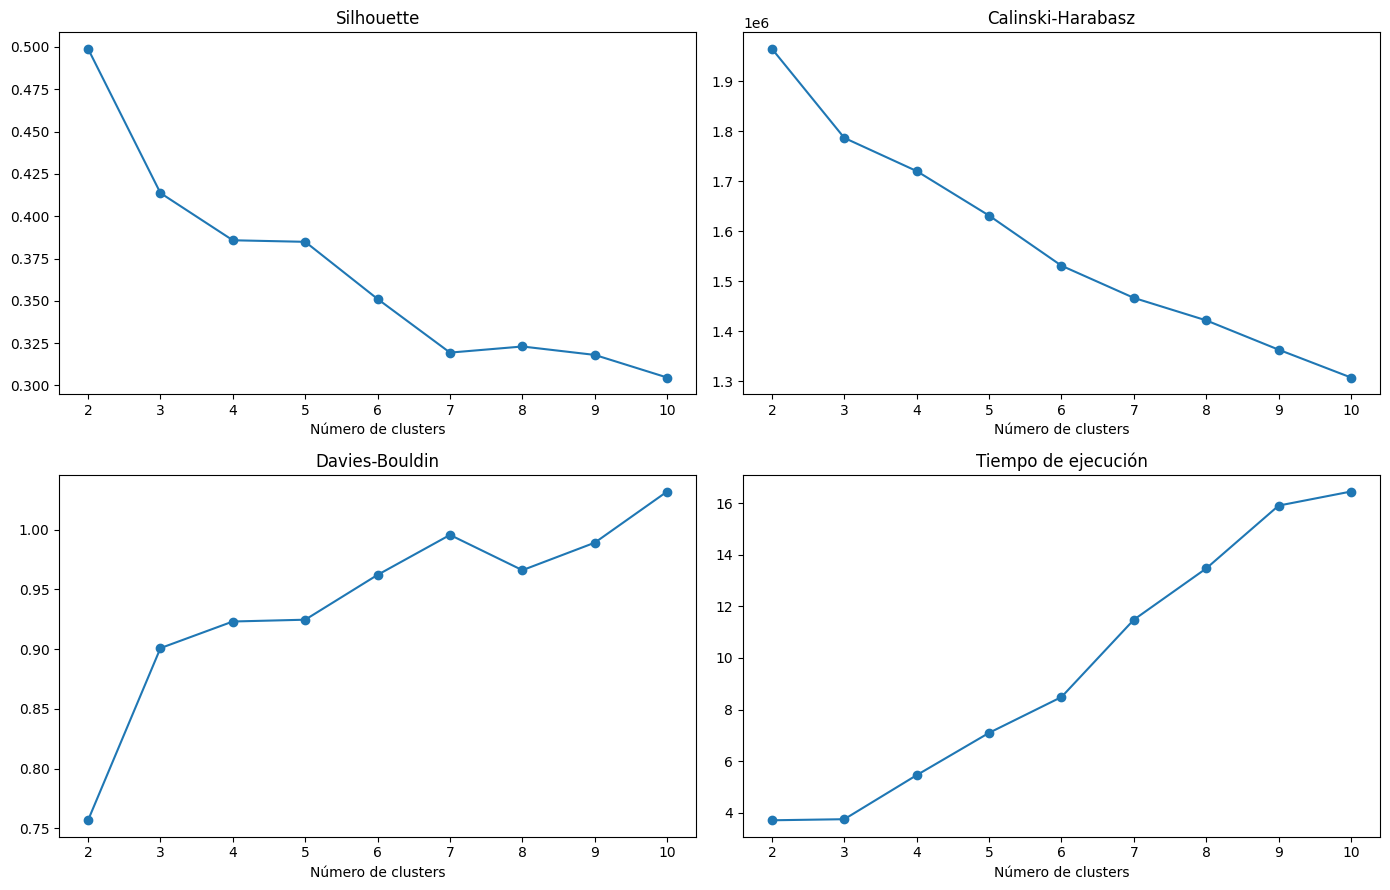

In [8]:
plot_clustering_metrics(resultados_kmeans)

## Ajuste final y perfil de los clusters


In [9]:
modelo, labels = fit_clustering_model(
    model_name="kmeans",
    k=2,
    X=X
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels,
    df_scaled,
    df_simple,
    id_col="customer_id"
)

print(f"K-MEANS CON k = {2}")
print("\nTamaño de los clusters:")
display(cluster_sizes)

print("\nPorcentaje de clientes:")
display(porcentajes)

print("\nPerfil medio de los clusters:")
display(perfil_clusters)

K-MEANS CON k = 2

Tamaño de los clusters:


cluster
0    811151
1    551130
Name: count, dtype: int64


Porcentaje de clientes:


cluster
0    59.54
1    40.46
Name: proportion, dtype: float64


Perfil medio de los clusters:


,recency,frequency,monetary
cluster,,,
0,343.994,1.868,0.150
1,77.422,13.726,1.384


- Cluster 0 – Clientes poco activos y de bajo valor: presentan una recencia muy elevada, una frecuencia de compra muy baja y un gasto total reducido. Representan clientes que compran de forma muy esporádica y cuya relación reciente con H&M es limitada.
- Cluster 1 – Clientes frecuentes y de alto valor: presentan una recencia mucho menor, una frecuencia de compra claramente superior y un gasto total muy elevado en comparación con el otro grupo. Representan, por tanto, el segmento de clientes más activos, recurrentes y valiosos.